In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import chardet
import seaborn as sns

In [2]:
geneset=pd.read_csv('genesets/lim_cds_geneset.txt',header=0,sep='\t')

In [3]:
set_overlap={}
for c1 in geneset.columns:
    set_overlap[c1]={}
    for c2 in geneset.columns:
        set_overlap[c1][c2]=len(set(geneset[c1].dropna()).intersection(set(geneset[c2].dropna())))
max_overlap={}
for c1 in geneset.columns:
    max_overlap[c1]={}
    for c2 in geneset.columns:
        max_overlap[c1][c2]=len(set(geneset[c1].dropna()).union(set(geneset[c2].dropna())))

In [4]:
pairwiseov=pd.DataFrame(set_overlap)
norm=pd.DataFrame(max_overlap)

In [5]:
norm

,rev_CTL,HALLMARK_APOPTOSIS,REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,Rev_Pyroptosis,REACTOME_REGULATED_NECROSIS,Rev_Ferroptosis
rev_CTL,56,214,197,106,109,120
HALLMARK_APOPTOSIS,214,161,302,198,203,220
REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,197,302,143,193,200,207
Rev_Pyroptosis,106,198,193,51,80,113
REACTOME_REGULATED_NECROSIS,109,203,200,80,58,121
Rev_Ferroptosis,120,220,207,113,121,64


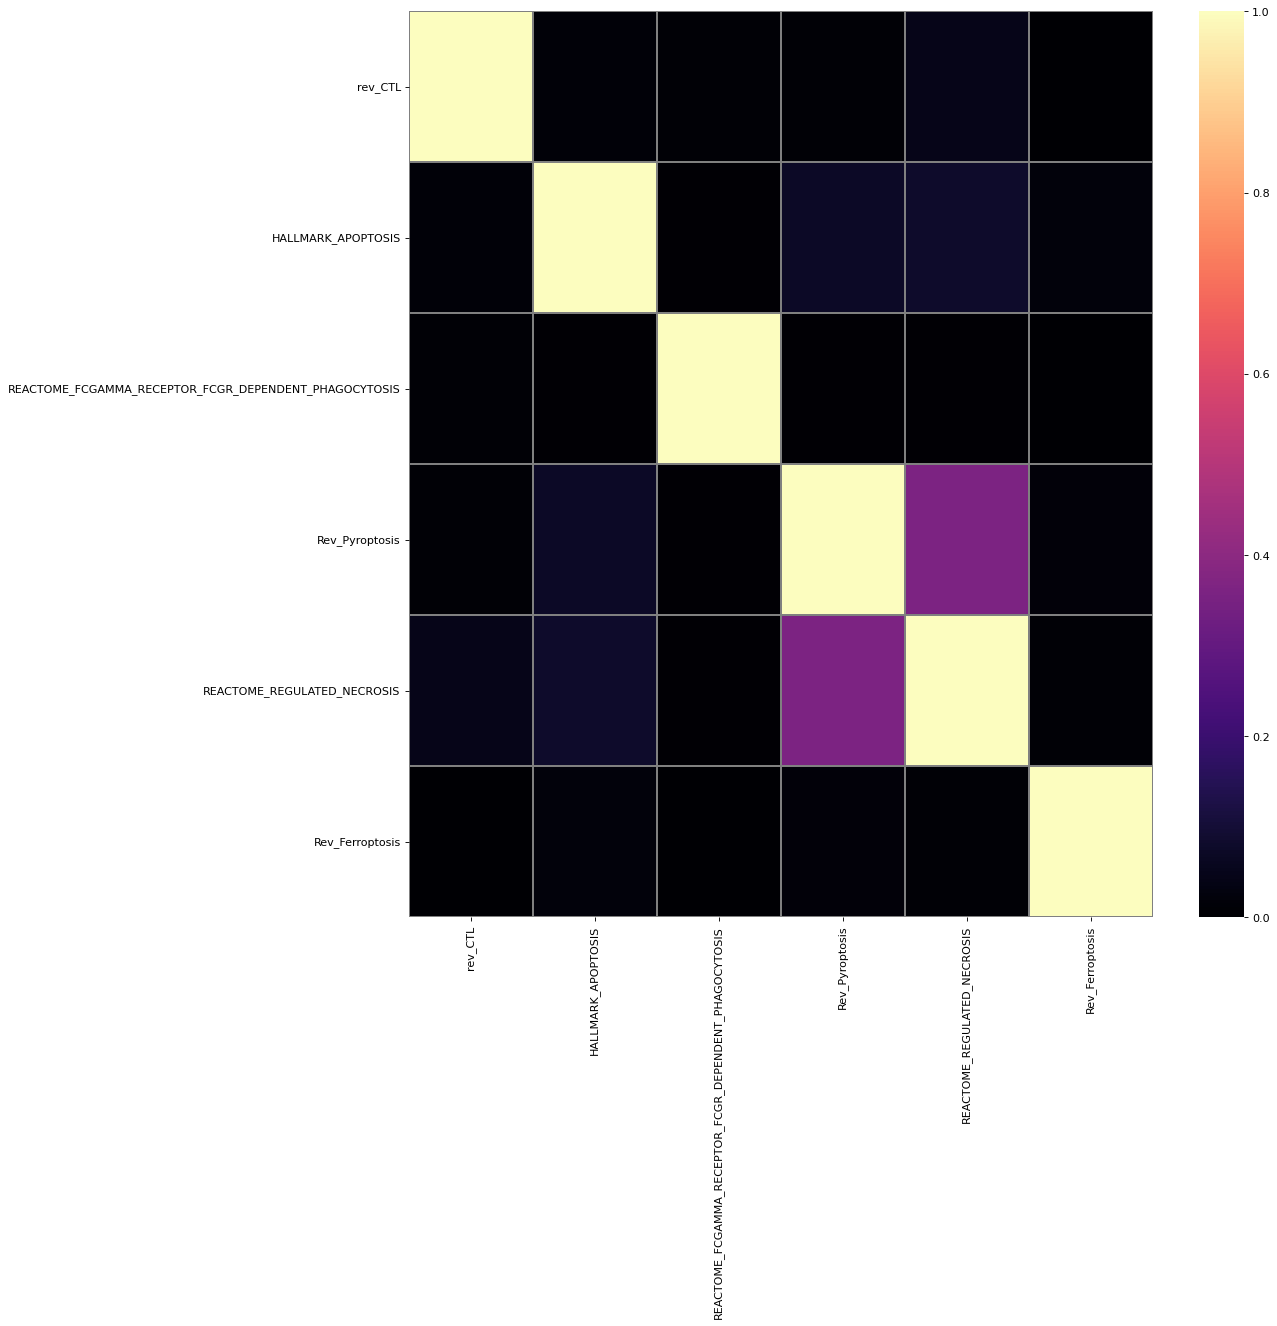

In [6]:
nomroverlap=pairwiseov/norm
fig = plt.figure(num=None, figsize=(15, 15), dpi=80, facecolor='w', edgecolor='k')
res = sns.heatmap(nomroverlap.transpose(), cmap='magma',linewidths=0.1, linecolor='gray', xticklabels=True, yticklabels=True)
fig.savefig("heatmap_overlap.png")

In [9]:
rawdata = open("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TcgaTargetGTEX_phenotype_rev.csv", "rb").read()
chardet.detect(rawdata)

{'encoding': 'ISO-8859-1', 'confidence': 0.7285962189153715, 'language': ''}

In [6]:
cat_sample=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TcgaTargetGTEX_phenotype_rev.csv",index_col=0,encoding='ISO-8859-1')

In [8]:
cat_sample

,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
sample,,,,,,
TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
...,...,...,...,...,...,...
TARGET-20-PANPKN-09,Acute Myeloid Leukemia,Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Bone Marrow,Male,TARGET
TARGET-20-PANLIR-09,Acute Myeloid Leukemia,Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Bone Marrow,Male,TARGET
TARGET-20-PAPAWN-09,Acute Myeloid Leukemia,Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Bone Marrow,Male,TARGET


In [7]:
genexpmatrix=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TCGA-GTEx-TARGET-gene-exp-counts.deseq2-normalized.log2.gz",sep="\t",index_col=0)

In [10]:
cat_sample.dropna(inplace=True,how='all')
cat_sdict=dict(cat_sample['primary disease or tissue']+"_"+cat_sample['_primary_site']+"_"+cat_sample['_sample_type'])

In [11]:
genexpmatrix.index=genexpmatrix.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()

In [12]:
can_dict={}
can_dict_counts={}
for s in cat_sdict:
    if cat_sdict[s] not in can_dict.keys():
        can_dict[cat_sdict[s]]=[]
        can_dict[cat_sdict[s]].append(s)
    else:
        can_dict[cat_sdict[s]].append(s)
for c in can_dict:
    can_dict_counts[c]=len(can_dict[c])

In [ ]:
can_dict["Breast Invasive Carcinoma_Breast_Primary Tumor"]

In [13]:
tcgagenemap=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/probeMap_gencode.v23.annotation.gene.probemap",sep="\t",index_col=0)
enslist=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
print(len(enslist))#ensids
print(len(list(set(enslist))))#unique ensids
tcgaensdict=dict(zip(tcgagenemap['gene'].values.tolist(),enslist))

60498
60498


In [13]:
tcgaensdict

{'DDX11L1': 'ENSG00000223972',
 'WASH7P': 'ENSG00000226210',
 'MIR6859-1': 'ENSG00000278267',
 'RP11-34P13.3': 'ENSG00000243485',
 'MIR1302-2': 'ENSG00000274890',
 'FAM138A': 'ENSG00000237613',
 'OR4G4P': 'ENSG00000268020',
 'OR4G11P': 'ENSG00000240361',
 'OR4F5': 'ENSG00000186092',
 'RP11-34P13.7': 'ENSG00000238009',
 'RP11-34P13.8': 'ENSG00000239945',
 'CICP27': 'ENSG00000233750',
 'RP11-34P13.15': 'ENSG00000268903',
 'RP11-34P13.16': 'ENSG00000269981',
 'RP11-34P13.14': 'ENSG00000239906',
 'RP11-34P13.13': 'ENSG00000241860',
 'RNU6-1100P': 'ENSG00000222623',
 'RP11-34P13.9': 'ENSG00000241599',
 'FO538757.3': 'ENSG00000279928',
 'FO538757.2': 'ENSG00000279457',
 'MIR6859-2': 'ENSG00000273874',
 'FO538757.1': 'ENSG00000275135',
 'AP006222.2': 'ENSG00000228463',
 'RPL23AP21': 'ENSG00000241670',
 'RPL23AP24': 'ENSG00000236679',
 'RP5-857K21.15': 'ENSG00000236743',
 'RP4-669L17.2': 'ENSG00000236601',
 'RP4-669L17.10': 'ENSG00000237094',
 'WBP1LP7': 'ENSG00000269732',
 'OR4F29': 'ENSG0000

In [14]:
genesetdict={}
for c in geneset.columns:
    genesetdict[c]=list(geneset[c].dropna().values)

In [15]:
genesetdict

{'rev_CTL': ['AGER',
  'AZGP1',
  'B2M',
  'CD1A',
  'CD1B',
  'CD1C',
  'CD1D',
  'CD1E',
  'CEACAM1',
  'CTSC',
  'CTSH',
  'CYRIB',
  'EMP2',
  'FADD',
  'FCGR2B',
  'GZMM',
  'HLA-A',
  'HLA-B',
  'HLA-DRA',
  'HLA-DRB1',
  'HLA-E',
  'HLA-F',
  'HLA-G',
  'HLA-H',
  'HPRT1',
  'IL12A',
  'IL12B',
  'IL12RB1',
  'IL23A',
  'IL23R',
  'IL7R',
  'KLRC1',
  'KLRD1',
  'LILRB1',
  'MICA',
  'MR1',
  'NECTIN2',
  'PPP3CB',
  'PRF1',
  'PTPRC',
  'PVR',
  'RAB27A',
  'RIPK3',
  'SLC22A13',
  'STX7',
  'XCL1',
  'CD247',
  'CD3D',
  'CD3E',
  'CD3G',
  'FAS',
  'FASLG',
  'GZMB',
  'ICAM1',
  'ITGAL',
  'ITGB2'],
 'HALLMARK_APOPTOSIS': ['ADD1',
  'AIFM3',
  'ANKH',
  'ANXA1',
  'APP',
  'ATF3',
  'AVPR1A',
  'BAX',
  'BCAP31',
  'BCL10',
  'BCL2L1',
  'BCL2L10',
  'BCL2L11',
  'BCL2L2',
  'BGN',
  'BID',
  'BIK',
  'BIRC3',
  'BMF',
  'BMP2',
  'BNIP3L',
  'BRCA1',
  'BTG2',
  'BTG3',
  'CASP1',
  'CASP2',
  'CASP3',
  'CASP4',
  'CASP6',
  'CASP7',
  'CASP8',
  'CASP9',
  'CAV1',
  'CCNA

In [16]:
gsgenemap={}
for gs in genesetdict:
    for g in genesetdict[gs]:
        try:
            gsgenemap[g]=tcgaensdict[g]
        except:
            print(g)

CYRIB
NECTIN2
H1-0
PLPPR4
PLPP4
PLPP5
GSDME
PJVK
GSDME
AKR1C1-3
ALOXs
CD44v
GCLC/GCLM
HSPB5
KOD
SQS
TTC35


In [17]:
#partial hotfix comeback
gsgenemap['PRKN']='ENSG00000185345'
gsgenemap['TOMM70']='ENSG00000196683'
gsgenemap['TUBB8B']='ENSG00000173213'
gsgenemap['H1-0']='ENSG00000189060'
gsgenemap['PLPPR4']='ENSG00000117600'
gsgenemap['PLPP4']='ENSG00000203805'
gsgenemap['PLPP5']='ENSG00000147535'
gsgenemap['CYRIB']='ENSG00000153310'
gsgenemap['NECTIN2']='ENSG00000130202'
gsgenemap['MIR3606']='ENSG00000284180'
gsgenemap['GSDME']='ENSG00000105928'
#HLADRB3,4 missing in ensembl

In [18]:
ensgeneset={}
for gs in genesetdict:
    if gs not in ensgeneset.keys():
        ensgeneset[gs]=[]
    for g in genesetdict[gs]:
        try:
            ensgeneset[gs].append(gsgenemap[g])
        except:
            print(g)

PJVK
AKR1C1-3
ALOXs
CD44v
GCLC/GCLM
HSPB5
KOD
SQS
TTC35


In [19]:
countens={}
for gs in ensgeneset:
    for g in ensgeneset[gs]:
        if g in countens:
            countens[g]+=1
        else:
            countens[g]=1

In [20]:
nodup_ensgeneset={}
for gs in ensgeneset:
    if gs not in nodup_ensgeneset.keys():
        nodup_ensgeneset[gs]=[]
    for g in ensgeneset[gs]:
        if countens[g]==1:
            nodup_ensgeneset[gs].append(g)

([<matplotlib.axis.XTick at 0x1457c7e20>,
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

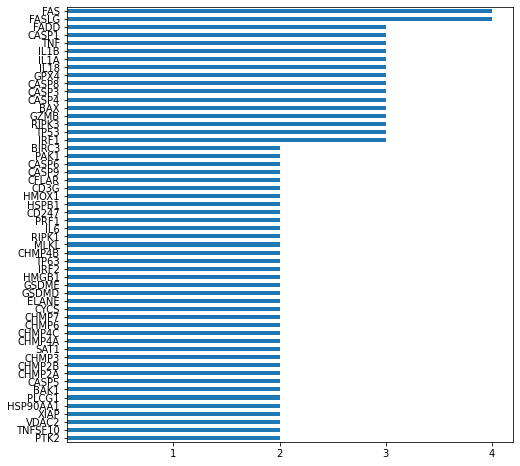

In [22]:
plt.rcParams["figure.figsize"] = (8,8)
countgs={}
for gs in genesetdict.keys():
    for g in genesetdict[gs]:
        if g in countgs:
            countgs[g]+=1
        else:
            countgs[g]=1
countser=pd.Series(countgs)
countser[countser>1].sort_values().plot.barh()
plt.xticks([1,2,3,4])

In [14]:
tcgagenemap.index=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()

In [24]:
tcgagenemap.loc['ENSG00000203805']

gene           PPAPDC1A
chrom             chr10
chromStart    120456954
chromEnd      120589855
strand                +
Name: ENSG00000203805, dtype: object

In [15]:
candf=pd.Series(can_dict_counts)
candf.sort_values(inplace=True)
matrixlist=list(candf.loc[candf>=10].index)

In [16]:
#save matrix
for mtype in matrixlist:
    genexpmatrix.loc[:,genexpmatrix.columns.intersection(can_dict[mtype])].to_csv("deseqgeneexp/"+mtype+"_geneexp.tsv",sep="\t")

In [77]:
#save_matrix
for mtype in matrixlist:
        genexpmatrix.loc[genexpmatrix.index.intersection(list(gsgenemap.values())),genexpmatrix.columns.intersection(can_dict[mtype])].to_csv("gs_geneexp/"+mtype+"_geneexp.tsv",sep="\t")

In [70]:
genexpmatrix.index.intersection(gsgenemap.keys())

Index([], dtype='object')

In [71]:
genexpmatrix.head()

,TCGA-AD-5900-01,TCGA-BP-4968-01,TCGA-NG-A4VU-01,TCGA-CG-4305-01,TCGA-AO-A03M-01,TCGA-ZH-A8Y6-01,TCGA-HT-7686-01,TCGA-BR-6458-11,TCGA-29-1699-01,TCGA-KK-A6E1-01,...,TARGET-20-PANLIZ-04,TARGET-21-PASSLT-41,TARGET-20-PASTTW-09,TARGET-50-PAKYLT-01,TARGET-20-PATJHJ-09,TARGET-21-PATKKJ-41,TARGET-10-PAPEJN-04,TARGET-20-PABLDZ-09,TARGET-10-PANSBR-09,TARGET-10-PARFLV-04
ENSG00000242268.2,0.0000,1.8076,0.0000,0.9198,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,1.4704,0.0000,0.0000,0.0000,0.0000,0.0000,1.3737,0.0000
ENSG00000259041.1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ENSG00000270112.3,0.0000,2.3695,4.0418,0.0000,0.6768,0.8646,2.5249,0.0000,4.4577,2.0054,...,0.0000,0.0000,0.0000,5.8642,0.0000,0.0000,2.2529,0.0000,2.3157,3.0839
ENSG00000167578.16,9.3875,10.9093,8.3520,9.2926,10.1251,10.4942,10.8458,10.8855,12.3838,11.0233,...,8.9332,10.2905,8.2429,9.3763,11.6929,9.6767,9.6251,9.9499,10.1733,8.8034
ENSG00000278814.1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [75]:
genexpmatrix.index=genexpmatrix.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()

In [73]:
genexpmatrix.head()

,TCGA-AD-5900-01,TCGA-BP-4968-01,TCGA-NG-A4VU-01,TCGA-CG-4305-01,TCGA-AO-A03M-01,TCGA-ZH-A8Y6-01,TCGA-HT-7686-01,TCGA-BR-6458-11,TCGA-29-1699-01,TCGA-KK-A6E1-01,...,TARGET-20-PANLIZ-04,TARGET-21-PASSLT-41,TARGET-20-PASTTW-09,TARGET-50-PAKYLT-01,TARGET-20-PATJHJ-09,TARGET-21-PATKKJ-41,TARGET-10-PAPEJN-04,TARGET-20-PABLDZ-09,TARGET-10-PANSBR-09,TARGET-10-PARFLV-04
ENSG00000223972,0.0000,1.8076,0.0000,0.9198,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,1.4704,0.0000,0.0000,0.0000,0.0000,0.0000,1.3737,0.0000
ENSG00000227232,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ENSG00000278267,0.0000,2.3695,4.0418,0.0000,0.6768,0.8646,2.5249,0.0000,4.4577,2.0054,...,0.0000,0.0000,0.0000,5.8642,0.0000,0.0000,2.2529,0.0000,2.3157,3.0839
ENSG00000243485,9.3875,10.9093,8.3520,9.2926,10.1251,10.4942,10.8458,10.8855,12.3838,11.0233,...,8.9332,10.2905,8.2429,9.3763,11.6929,9.6767,9.6251,9.9499,10.1733,8.8034
ENSG00000274890,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [26]:
allcorelist = [item for sublist in nodup_ensgeneset.values() for item in sublist]

In [27]:
len(allcorelist)

403

In [28]:
tumour_subtype=pd.read_csv('/Users/jayashankara2/Desktop/Hannenhalli_rotation/subtype_purity/pancan2018_subtypes.tsv',sep='\t',index_col=0)
samlist=tumour_subtype.index.to_series().apply(lambda x: x[:12]).values.tolist()
tumour_subtype.index=samlist
tumour_subtype.head()

,cancer.type,Subtype_mRNA,Subtype_DNAmeth,Subtype_protein,Subtype_miRNA,Subtype_CNA,Subtype_Integrative,Subtype_other,Subtype_Selected
TCGA-OR-A5J1,ACC,steroid-phenotype-high+proliferation,CIMP-high,NaN,miRNA_1,Quiet,COC3,C1A,ACC.CIMP-high
TCGA-OR-A5J2,ACC,steroid-phenotype-high+proliferation,CIMP-low,1.0,miRNA_1,Noisy,COC3,C1A,ACC.CIMP-low
TCGA-OR-A5J3,ACC,steroid-phenotype-high,CIMP-intermediate,3.0,miRNA_6,Chromosomal,COC2,C1A,ACC.CIMP-intermediate
TCGA-OR-A5J4,ACC,NaN,CIMP-high,NaN,miRNA_6,Chromosomal,NaN,NaN,ACC.CIMP-high
TCGA-OR-A5J5,ACC,steroid-phenotype-high,CIMP-intermediate,NaN,miRNA_2,Chromosomal,COC2,C1A,ACC.CIMP-intermediate


In [45]:
from matplotlib.patches import Patch
for mtype in matrixlist:
    ctypedata=pd.read_csv("geneexp/"+mtype+"_geneexp.tsv",sep="\t",index_col=0)
    test2=ctypedata.loc[ctypedata.index.intersection(allcorelist)].reindex(allcorelist)
    samlist1=test2.columns.to_series().apply(lambda x: x[:12]).values.tolist()
    test2.columns=samlist1
    tssubset=tumour_subtype.loc[tumour_subtype.index.intersection(test2.columns.tolist()),'Subtype_Selected']
    st_map=tssubset.to_dict()
    for c in test2.columns:
        if c not in st_map.keys():
            st_map[c]="NA"
    subtypelabs=list(set(list(st_map.values())))
    clrs=sns.color_palette("muted", len(subtypelabs))
    lut = dict(zip(subtypelabs, list(clrs.as_hex())))
    stc_map={}
    for c in test2.columns:
        stc_map[c]=lut[st_map[c]]
    cc = test2.columns.map(stc_map)
    clrs2=sns.color_palette("Set2", len(nodup_ensgeneset))
    genesetlabs=list(nodup_ensgeneset.keys())
    glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
    gcmap={}
    for g in test2.index:
        for gs in nodup_ensgeneset.keys():
            if g in nodup_ensgeneset[gs]:
                gslab=gs
                break
        gcmap[g]=glut[gs]
    rc = test2.index.map(gcmap)
    g=sns.clustermap(test2,figsize=(20,20),yticklabels=False,row_colors=rc,col_colors=cc,row_cluster=False)
    handles1 = [Patch(facecolor=lut[name]) for name in lut]
    handles2 = [Patch(facecolor=glut[name]) for name in glut]
    first_legend=plt.legend(handles1, lut, title='Subtype',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')
    axl = plt.gca().add_artist(first_legend)
    plt.legend(handles2, glut, title='geneset',bbox_to_anchor=(0, 0),bbox_transform=plt.gcf().transFigure, loc='lower left')
    plt.tight_layout()
    g.savefig("heatmaps/"+mtype+"_celldeathsigs.png")
    plt.close()

/var/folders/75/2z9jf7bx0sqf07ypmf4yqgyhwmbx65/T/ipykernel_4616/785909935.py:36: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  plt.tight_layout()


In [30]:
filedicts={}
for f in os.listdir("/Users/jayashankara2/Desktop/Hannenhalli_rotation/snv-cancer/"):
    if f[:-11] not in filedicts.keys():
        filedicts[f[:-11]]=[]
        filedicts[f[:-11]].append(f)
    else:
        filedicts[f[:-11]].append(f)

In [31]:
for f in os.listdir("/Users/jayashankara2/Desktop/Hannenhalli_rotation/gistic-cnv-cancer/"):
    filedicts[f[:-11]].append(f)

In [32]:
tcgapcode=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genexp/tcga_projectcodes.txt",sep="\t",index_col=0)

In [33]:
combgenexfiles={}
for file in os.listdir("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genexp_lists/"):
    if file.endswith(".txt"):
        combgenexfiles[file[:-4]]=[]
        for line in open("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genexp_lists/"+file):
            line=line.strip()
            combgenexfiles[file[:-4]].append(line)

In [34]:
combgenexfiles

{'luad': ['Lung Adenocarcinoma_Lung_Solid Tissue Normal',
  'Lung_Lung_Normal Tissue',
  'Lung Adenocarcinoma_Lung_Primary Tumor'],
 'lusc': ['Lung Squamous Cell Carcinoma_Lung_Primary Tumor',
  'Lung Squamous Cell Carcinoma_Lung_Solid Tissue Normal',
  'Lung_Lung_Normal Tissue'],
 'ucec': ['Uterine Corpus Endometrioid Carcinoma_Endometrium_Solid Tissue Normal',
  'Uterine Carcinosarcoma_Uterus_Primary Tumor',
  'Uterus_Uterus_Normal Tissue',
  'Uterine Corpus Endometrioid Carcinoma_Endometrium_Primary Tumor'],
 'brca': ['Breast Invasive Carcinoma_Breast_Solid Tissue Normal',
  'Breast - Mammary Tissue_Breast_Normal Tissue',
  'Breast Invasive Carcinoma_Breast_Primary Tumor'],
 'kirc': ['Kidney Clear Cell Carcinoma_Kidney_Primary Tumor',
  'Kidney Clear Cell Carcinoma_Kidney_Solid Tissue Normal',
  'Kidney - Cortex_Kidney_Normal Tissue'],
 'paad': ['Pancreas_Pancreas_Normal Tissue',
  'Pancreatic Adenocarcinoma_Pancreas_Primary Tumor'],
 'lihc': ['Liver Hepatocellular Carcinoma_Liver_S

In [44]:
for mtype in combgenexfiles:
    allgextype=[]
    coldata={}
    for m in combgenexfiles[mtype]:
        ctypedata=pd.read_csv("geneexp/"+m+"_geneexp.tsv",sep="\t",index_col=0)
        test2=ctypedata.loc[ctypedata.index.intersection(allcorelist)].copy()
        allgextype.append(test2)
        coldata[m]=test2.columns.tolist()
    combined_gex=pd.concat(allgextype,axis=1)
    combined_gex.fillna(-10,inplace=True)
    combined_gex1=combined_gex.reindex(allcorelist)
    clrs=sns.color_palette("muted", len(coldata))
    lut = dict(zip(list(coldata.keys()), list(clrs.as_hex())))
    stc_map={}
    for c in combined_gex1.columns:
        for m in coldata:
            if c in coldata[m]:
                stc_map[c]=lut[m]
    cc = combined_gex1.columns.map(stc_map)
    clrs2=sns.color_palette("Set2", len(nodup_ensgeneset))
    genesetlabs=list(nodup_ensgeneset.keys())
    glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
    gcmap={}
    for g in combined_gex1.index:
        for gs in nodup_ensgeneset.keys():
            if g in nodup_ensgeneset[gs]:
                gslab=gs
                break
        gcmap[g]=glut[gs]
    rc = combined_gex1.index.map(gcmap)
    g=sns.clustermap(combined_gex1,figsize=(20,20),yticklabels=False,row_colors=rc,col_colors=cc,row_cluster=False)
    handles1 = [Patch(facecolor=lut[name]) for name in lut]
    handles2 = [Patch(facecolor=glut[name]) for name in glut]
    first_legend=plt.legend(handles1, lut, title='sampletype',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')
    axl = plt.gca().add_artist(first_legend)
    plt.legend(handles2, glut, title='geneset',bbox_to_anchor=(0, 0),bbox_transform=plt.gcf().transFigure, loc='lower left')
    plt.tight_layout()
    g.savefig("heatmaps/"+mtype+"_celldeathsigs.png")
    plt.close()

/Users/jayashankara2/Desktop/Projectideas/celldeathmechas/celldeath/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/var/folders/75/2z9jf7bx0sqf07ypmf4yqgyhwmbx65/T/ipykernel_4616/3817398498.py:37: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  plt.tight_layout()


In [41]:
#ssgsea
for mtype in combgenexfiles:
    allgextype=[]
    coldata={}
    for m in combgenexfiles[mtype]:
        ctypedata=pd.read_csv("ssgsea/"+m+"_geneexp _ssgsea_mat.tsv",sep="\t",index_col=0)
        allgextype.append(ctypedata)
        coldata[m]=ctypedata.columns.tolist()
    combined_gex=pd.concat(allgextype,axis=1)
    clrs=sns.color_palette("muted", len(coldata))
    lut = dict(zip(list(coldata.keys()), list(clrs.as_hex())))
    stc_map={}
    for c in combined_gex.columns:
        for m in coldata:
            if c in coldata[m]:
                stc_map[c]=lut[m]
    cc = combined_gex.columns.map(stc_map)
    clrs2=sns.color_palette("Set2", len(combined_gex.columns))
    glut=dict(zip(combined_gex.index.tolist(), list(clrs2.as_hex())))
    gcmap={}
    for g in combined_gex.index:
        for gs in nodup_ensgeneset.keys():
            if g in nodup_ensgeneset[gs]:
                gslab=gs
                break
        gcmap[g]=glut[gs]
    rc = combined_gex.index.map(glut)
    g=sns.clustermap(combined_gex,figsize=(20,8),row_colors=rc,col_colors=cc,row_cluster=False)
    handles1 = [Patch(facecolor=lut[name]) for name in lut]
    handles2 = [Patch(facecolor=glut[name]) for name in glut]
    first_legend=plt.legend(handles1, lut, title='sampletype',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')
    axl = plt.gca().add_artist(first_legend)
    plt.legend(handles2, glut, title='geneset',bbox_to_anchor=(0, 0),bbox_transform=plt.gcf().transFigure, loc='lower left')
    plt.tight_layout()
    g.savefig("heatmaps/"+mtype+"_celldeathsigs_ssgsea.png")
    plt.close()

/var/folders/75/2z9jf7bx0sqf07ypmf4yqgyhwmbx65/T/ipykernel_4616/4108330177.py:34: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  plt.tight_layout()


In [37]:
tumour_subtype1=tumour_subtype.copy()
tumour_subtype1.index=tumour_subtype1.index.to_series().apply(lambda x: x.replace("-",".")).values.tolist()

In [38]:
tumour_subtype1

,cancer.type,Subtype_mRNA,Subtype_DNAmeth,Subtype_protein,Subtype_miRNA,Subtype_CNA,Subtype_Integrative,Subtype_other,Subtype_Selected
TCGA.OR.A5J1,ACC,steroid-phenotype-high+proliferation,CIMP-high,NaN,miRNA_1,Quiet,COC3,C1A,ACC.CIMP-high
TCGA.OR.A5J2,ACC,steroid-phenotype-high+proliferation,CIMP-low,1.0,miRNA_1,Noisy,COC3,C1A,ACC.CIMP-low
TCGA.OR.A5J3,ACC,steroid-phenotype-high,CIMP-intermediate,3.0,miRNA_6,Chromosomal,COC2,C1A,ACC.CIMP-intermediate
TCGA.OR.A5J4,ACC,NaN,CIMP-high,NaN,miRNA_6,Chromosomal,NaN,NaN,ACC.CIMP-high
TCGA.OR.A5J5,ACC,steroid-phenotype-high,CIMP-intermediate,NaN,miRNA_2,Chromosomal,COC2,C1A,ACC.CIMP-intermediate
...,...,...,...,...,...,...,...,...,...
TCGA.ND.A4WA,UCS,2,NaN,NaN,NaN,NaN,NaN,NaN,UCS.2
TCGA.NG.A4VU,UCS,1,NaN,NaN,NaN,NaN,NaN,NaN,UCS.1
TCGA.QN.A5NN,UCS,2,NaN,NaN,NaN,NaN,NaN,NaN,UCS.2
TCGA.NF.A5CP,UCS,2,NaN,NaN,NaN,NaN,NaN,NaN,UCS.2


In [40]:
from matplotlib.patches import Patch
for mtype in matrixlist:
    ctypedata=pd.read_csv("ssgsea/"+mtype+"_geneexp _ssgsea_mat.tsv",sep="\t",index_col=0)
    samlist1=ctypedata.columns.to_series().apply(lambda x: x[:12]).values.tolist()
    ctypedata.columns=samlist1
    tssubset=tumour_subtype1.loc[tumour_subtype1.index.intersection(ctypedata.columns.tolist()),'Subtype_Selected'].copy()
    st_map=tssubset.to_dict()
    for c in ctypedata.columns:
        if c not in st_map.keys():
            st_map[c]="NA"
    subtypelabs=list(set(list(st_map.values())))
    clrs=sns.color_palette("muted", len(subtypelabs))
    lut = dict(zip(subtypelabs, list(clrs.as_hex())))
    stc_map={}
    for c in ctypedata.columns:
        stc_map[c]=lut[st_map[c]]
    cc = ctypedata.columns.map(stc_map)
    clrs2=sns.color_palette("Set2", len(ctypedata.index))
    genesetlabs=ctypedata.index.tolist()
    glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
    gcmap={}
    for g in ctypedata.index:
        for gs in nodup_ensgeneset.keys():
            if g in nodup_ensgeneset[gs]:
                gslab=gs
                break
        gcmap[g]=glut[gs]
    rc = ctypedata.index.map(glut)
    g=sns.clustermap(ctypedata,figsize=(20,20),yticklabels=False,row_colors=rc,col_colors=cc,row_cluster=False)
    handles1 = [Patch(facecolor=lut[name]) for name in lut]
    handles2 = [Patch(facecolor=glut[name]) for name in glut]
    first_legend=plt.legend(handles1, lut, title='Subtype',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')
    axl = plt.gca().add_artist(first_legend)
    plt.legend(handles2, glut, title='geneset',bbox_to_anchor=(0, 0),bbox_transform=plt.gcf().transFigure, loc='lower left')
    plt.tight_layout()
    g.savefig("heatmaps/"+mtype+"_celldeathsigs_subtype.png")
    plt.close()

/var/folders/75/2z9jf7bx0sqf07ypmf4yqgyhwmbx65/T/ipykernel_4616/2358379540.py:35: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  plt.tight_layout()
/Users/jayashankara2/Desktop/Projectideas/celldeathmechas/celldeath/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


{'TCGA.3L.AA1B': 'GI.CIN',
 'TCGA.4N.A93T': 'GI.CIN',
 'TCGA.4T.AA8H': 'GI.CIN',
 'TCGA.5M.AAT4': 'GI.CIN',
 'TCGA.5M.AAT5': 'GI.CIN',
 'TCGA.5M.AAT6': 'GI.MSI',
 'TCGA.5M.AATA': 'GI.CIN',
 'TCGA.5M.AATE': 'GI.CIN',
 'TCGA.A6.2675': 'GI.CIN',
 'TCGA.A6.2685': 'GI.CIN',
 'TCGA.A6.2686': 'GI.MSI',
 'TCGA.A6.4105': 'GI.CIN',
 'TCGA.A6.5657': 'GI.CIN',
 'TCGA.A6.5660': 'GI.CIN',
 'TCGA.A6.5661': 'GI.MSI',
 'TCGA.A6.5662': 'GI.CIN',
 'TCGA.A6.5664': 'GI.GS',
 'TCGA.A6.5665': 'GI.MSI',
 'TCGA.A6.5666': 'GI.CIN',
 'TCGA.A6.5667': 'GI.CIN',
 'TCGA.A6.6137': 'GI.CIN',
 'TCGA.A6.6138': 'GI.CIN',
 'TCGA.A6.6142': 'GI.CIN',
 'TCGA.A6.6648': 'GI.CIN',
 'TCGA.A6.6649': 'GI.CIN',
 'TCGA.A6.6651': 'GI.CIN',
 'TCGA.A6.6652': 'GI.CIN',
 'TCGA.A6.6653': 'GI.MSI',
 'TCGA.A6.6654': 'GI.CIN',
 'TCGA.A6.6782': 'GI.CIN',
 'TCGA.A6.A565': 'GI.MSI',
 'TCGA.A6.A566': 'GI.GS',
 'TCGA.A6.A567': 'GI.CIN',
 'TCGA.A6.A56B': 'GI.CIN',
 'TCGA.AA.3489': 'GI.CIN',
 'TCGA.AA.3492': 'GI.MSI',
 'TCGA.AA.3496': 'GI.CIN',
 'T

/var/folders/75/2z9jf7bx0sqf07ypmf4yqgyhwmbx65/T/ipykernel_60376/565214370.py:3: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


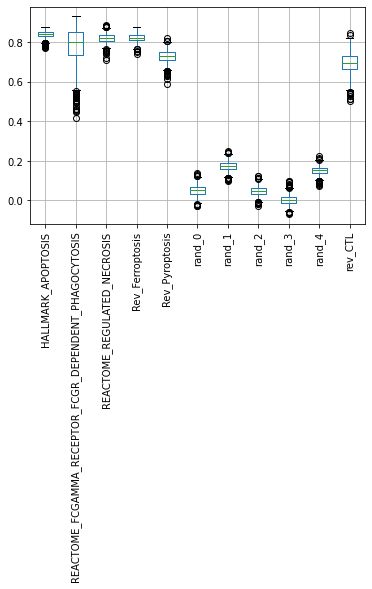

In [37]:
ss_brcapt.res2d.transpose().boxplot()
plt.xticks(rotation=90)
plt.tight_layout()

In [38]:
ss_brcasn.res2d.transpose().boxplot()
plt.xticks(rotation=90)
plt.tight_layout()

NameError: name 'ss_brcasn' is not defined

In [ ]:
ss_gtex_br = gp.ssgsea(data=gtexbreast,
               gene_sets=ensgeneset,
               outdir='test/ssgsea_gtexbreast',
               sample_norm_method='rank', # choose 'custom' for your own rank list
               permutation_num=0, # skip permutation procedure, because you don't need it
               no_plot=True, # skip plotting, because you don't need these figures
               processes=4, format='png', seed=9)

In [ ]:
ss_gtex_br.res2d

In [ ]:
ss_gtex_br.res2d.transpose().boxplot()
plt.xticks(rotation=90)
plt.tight_layout()

In [39]:
ss_brcapt2 = gp.ssgsea(data=brcapt,
               gene_sets=nodup_ensgeneset,
               outdir='test/ssgsea_brcapt',
               scale=False,
               processes=4, format='png', seed=9)
ss_brcasn2 = gp.ssgsea(data=brcasn,
               gene_sets=nodup_ensgeneset,
               outdir='test/ssgsea_brcasn',
               scale=False,
               processes=4, format='png', seed=9)
ss_gtex_br2 = gp.ssgsea(data=gtexbreast,
               gene_sets=nodup_ensgeneset,
               outdir='test/ssgsea_gtexbreast',
               scale=False,
               processes=4, format='png', seed=9)

[Text(1, 0, 'HALLMARK_APOPTOSIS'),
 Text(2, 0, 'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS'),
 Text(3, 0, 'REACTOME_REGULATED_NECROSIS'),
 Text(4, 0, 'Rev_Ferroptosis'),
 Text(5, 0, 'Rev_Pyroptosis'),
 Text(6, 0, 'rev_CTL')]

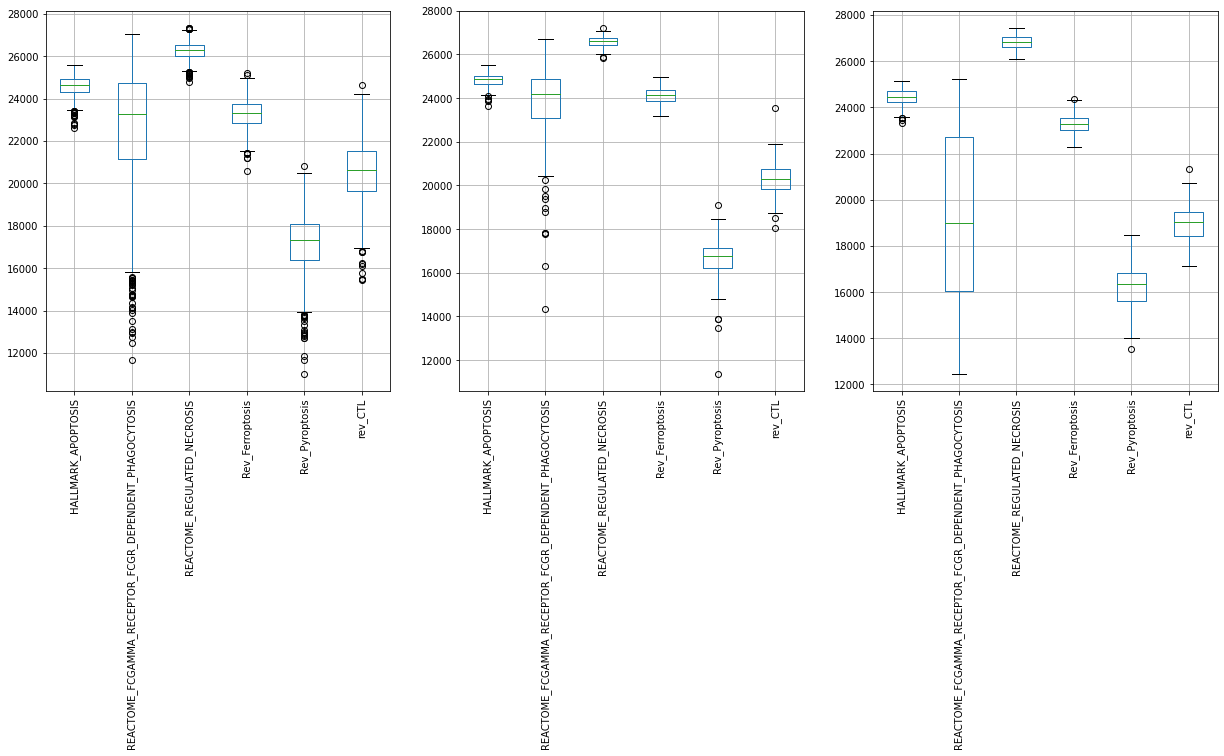

In [40]:
plt.rcParams["figure.figsize"] = (21,7)
fig, ax = plt.subplots(nrows=1, ncols=3)
pd.DataFrame(ss_brcapt2.resultsOnSamples).transpose().boxplot(ax=ax[0])
ax[0].set_xticklabels(labels=ss_brcapt2.res2d.index,rotation=90)
pd.DataFrame(ss_brcasn2.resultsOnSamples).transpose().boxplot(ax=ax[1])
ax[1].set_xticklabels(labels=ss_brcapt2.res2d.index,rotation=90)
pd.DataFrame(ss_gtex_br2.resultsOnSamples).transpose().boxplot(ax=ax[2])
ax[2].set_xticklabels(labels=ss_brcapt2.res2d.index,rotation=90)

In [ ]:
pd.DataFrame(ss_brcapt2.resultsOnSamples)

In [ ]:
def coxregsurvival_all(exp,surv,name,spgenes=[]):
    from sksurv.compare import compare_survival
    from sksurv.nonparametric import kaplan_meier_estimator
    from lifelines import CoxPHFitter
    import lifelines
    import sksurv as sk
    from sksurv.preprocessing import OneHotEncoder
    from matplotlib import gridspec
    import matplotlib.patches as patches
    surv['OS']=surv['OS']==1
    clindata=pd.read_csv("/home/arvindjs/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.basic_phenotype.tsv.gz", sep="\t", index_col=0)
    clindata.index=clindata.index.str.strip().str[:-1]
    clindata = clindata[~clindata.index.duplicated(keep='first')]
    if len(spgenes)!=0:
        exp=exp[spgenes]
    else:
        spgenes=exp.columns.to_list()
    #exp.drop('ENSG00000106304', axis=1, inplace=True)
    #print(exp)
    #return
    exp["age"]=clindata["Age at Diagnosis in Years"]
    exp["gender"]=clindata["Gender"]
    exp.dropna(inplace=True,subset=['gender'])
    exp.fillna(value={"age":-1}, inplace=True)
    exp["OS"]=surv["OS"]
    exp["OS.time"]=surv["OS.time"]
    exp['gender']=exp['gender'].astype("category")
    exp['OS']=exp['OS'].astype("category")
    exp.dropna(inplace=True)
    #print(exp)
    if len(spgenes)==0:
        return coxsummary
    geneexp={}
    quarts={}
    split={}
    spglist=[]
    for g in spgenes:
        if g in exp.columns.to_list():
            spglist.append(g)
            geneexp[g]=exp[g]
            quarts[g]=[geneexp[g].describe()["25%"],geneexp[g].describe()["75%"]]
            temp={}
            split[g]={}
            split[g]['high']=[]
            temp['high']=geneexp[g][geneexp[g]>=quarts[g][1]].index.tolist()
            split[g]['low']=[]
            temp['low']=geneexp[g][geneexp[g]<=quarts[g][0]].index.tolist()
            for lvl in split[g]:
                for x in temp[lvl]:
                    if x in surv.index.tolist():
                        split[g][lvl].append(x)
    pval_dict={}
    coxdict={}
    for l in spglist:
        fig = plt.figure()
        ax1 = fig.add_subplot()
        time=[]
        survival_prob=[]
        grp=[]
        for lvl in split[l]:
            t, s = kaplan_meier_estimator(surv.loc[split[l][lvl],"OS"],surv.loc[split[l][lvl],"OS.time"])
            ax1.step(t, s, where="post",label=lvl )
            surv.loc[split[l][lvl],'group']=lvl
            grp=grp+split[l][lvl]
        try:
            Xt = OneHotEncoder().fit_transform(exp[[l,"age","gender","OS","OS.time"]])
            cph = CoxPHFitter()
            coxsummary=cph.fit(Xt, duration_col='OS.time', event_col='OS=True').summary
            pval=compare_survival(surv.loc[grp,['OS','OS.time']].to_records(index=False), surv.loc[grp,'group'], return_stats=False)[1]
            if coxsummary.loc[l,['p']].values[0].round(5)>0.05 and pval>0.05:
                plt.close()
                continue
        except:
            continue
        for gs in ensgeneset:
            if l in ensgeneset[c]:
                tl=c+"_"+e[l]
        ax1.set_ylabel("est. probability of survival")
        ax1.set_xlabel("time days")
        ax1.legend(loc="best")
        pv=coxsummary.loc[l,['p']].values[0].round(3)
        chrv=coxsummary.loc[l,['exp(coef)']].values[0].round(3)
        ax1.set_title("\n".join(wrap("survival "+l+", "+tl+" CoxHR: "+str(chrv)+" ("+str(pv)+") Log rank P = "+str(pval.round(3)), 20)),fontsize=9)
        fig.savefig("plots/indsurvival/"+name+"_"+tl+".png")
        plt.close()
        pv=coxsummary.loc[l,['p']].values[0]
        chrv=coxsummary.loc[l,['exp(coef)']].values[0]
        coxdict[l]=[chrv,pval,pv]
    return coxdict

In [ ]:
from textwrap import wrap

In [113]:
tcga_brca_pt_aucell=pd.read_csv("Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp _Aucell.tsv",sep='\t')
tcga_brca_sn_aucell=pd.read_csv("Breast Invasive Carcinoma_Breast_Solid Tissue Normal_geneexp _Aucell.tsv",sep='\t')
gtex_breast_aucell=pd.read_csv("Breast - Mammary Tissue_Breast_Normal Tissue_geneexp _Aucell.tsv",sep='\t')

In [114]:
tcga_brca_pt_aucell

,TCGA.AO.A03M.01,TCGA.AO.A0JD.01,TCGA.A2.A0CT.01,TCGA.B6.A40B.01,TCGA.LQ.A4E4.01,TCGA.AO.A0JJ.01,TCGA.AC.A3QQ.01,TCGA.E9.A3QA.01,TCGA.GM.A2DD.01,TCGA.BH.A0BO.01,...,TCGA.XX.A89A.01,TCGA.BH.A0HF.01,TCGA.C8.A274.01,TCGA.D8.A27N.01,TCGA.GM.A2DK.01,TCGA.A2.A1FZ.01,TCGA.BH.A0HU.01,TCGA.BH.A18V.01,TCGA.BH.A18J.01,TCGA.BH.A18T.01
BIOCARTA_CTL_PATHWAY,0.150510,0.136175,0.129070,0.125919,0.106148,0.148780,0.071671,0.262095,0.169540,0.211863,...,0.167871,0.157059,0.104912,0.153908,0.148347,0.137597,0.143713,0.217362,0.140377,0.147915
GOBP_T_CELL_MEDIATED_CYTOTOXICITY,0.139951,0.144182,0.118036,0.160817,0.121508,0.160980,0.074387,0.160130,0.188591,0.156442,...,0.157834,0.161559,0.132773,0.154453,0.178139,0.155049,0.166079,0.188157,0.138685,0.115631
GOBP_NECROPTOTIC_SIGNALING_PATHWAY,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HALLMARK_APOPTOSIS,0.157802,0.120141,0.158306,0.209340,0.142449,0.199321,0.162889,0.159358,0.181134,0.219085,...,0.201258,0.195457,0.128990,0.185556,0.191336,0.201011,0.152902,0.149092,0.158435,0.098681
REACTOME_AUTOPHAGY,0.146928,0.128484,0.124973,0.118025,0.108526,0.111142,0.058354,0.118164,0.127248,0.115935,...,0.104368,0.127935,0.117506,0.122790,0.139716,0.116813,0.130141,0.106401,0.119983,0.123257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T cells gamma delta,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080622,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Dendritic cells resting,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039484,0.027359,0.000000,...,0.010399,0.001190,0.000000,0.000000,0.000000,0.004605,0.000000,0.029546,0.000000,0.000000
Dendritic cells activated,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008417,0.000000,0.041079,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060008,0.000000,0.019855
Eosinophils,0.000000,0.000000,0.000000,0.015320,0.000000,0.000000,0.028839,0.000000,0.013180,0.027978,...,0.022471,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [122]:
tcga_brca_pt_aucell.fillna(0,inplace=True,axis=1)
tcga_brca_sn_aucell.fillna(0,inplace=True,axis=1)
gtex_breast_aucell.fillna(0,inplace=True,axis=1)
tcga_brca_pt_aucell=tcga_brca_pt_aucell.transpose()
tcga_brca_sn_aucell=tcga_brca_sn_aucell.transpose()
gtex_breast_aucell=gtex_breast_aucell.transpose()
tcga_brca_pt_aucell['type']="Primary Tumour"
tcga_brca_sn_aucell['type']="Adjacent Solid Normal"
gtex_breast_aucell['type']="gtex healthy"
allaucell = pd.concat([tcga_brca_pt_aucell,tcga_brca_sn_aucell,gtex_breast_aucell],ignore_index=True)

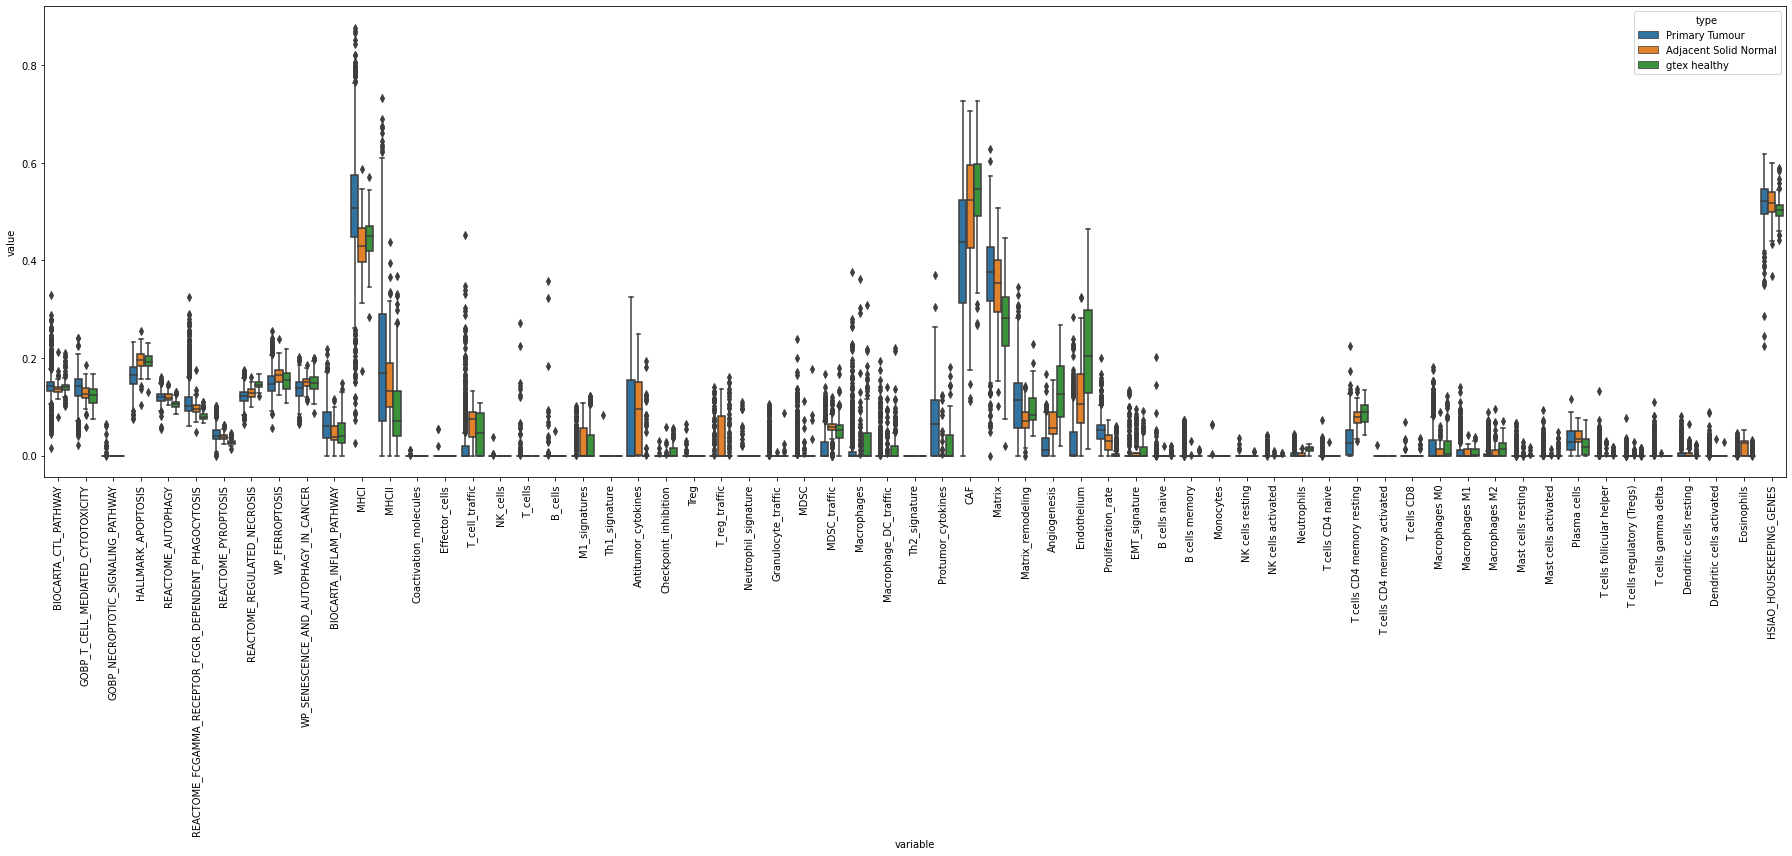

In [125]:
dd=pd.melt(allaucell,id_vars=['type'],value_vars=list(allgex.columns))
plt.figure(figsize=(25,12))
res=sns.boxplot(x='variable',y='value',data=dd, hue='type')
plt.xticks(rotation=90)
plt.tight_layout()
res.figure.savefig("aucell_geneset.png")

[Text(1, 0, 'BIOCARTA_CTL_PATHWAY'),
 Text(2, 0, 'GOBP_T_CELL_MEDIATED_CYTOTOXICITY'),
 Text(3, 0, 'GOBP_NECROPTOTIC_SIGNALING_PATHWAY'),
 Text(4, 0, 'HALLMARK_APOPTOSIS'),
 Text(5, 0, 'REACTOME_AUTOPHAGY'),
 Text(6, 0, 'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS'),
 Text(7, 0, 'REACTOME_PYROPTOSIS'),
 Text(8, 0, 'REACTOME_REGULATED_NECROSIS'),
 Text(9, 0, 'WP_FERROPTOSIS'),
 Text(10, 0, 'WP_SENESCENCE_AND_AUTOPHAGY_IN_CANCER'),
 Text(11, 0, 'BIOCARTA_INFLAM_PATHWAY')]

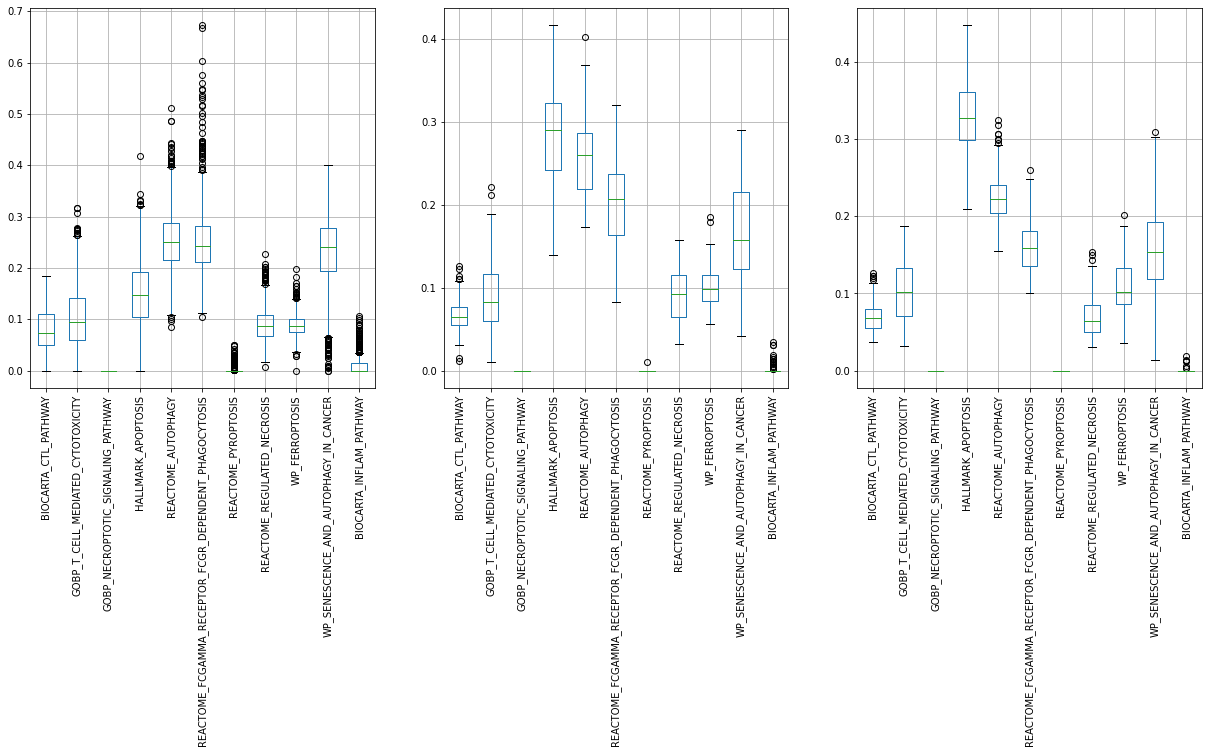

In [221]:
#aucell
plt.rcParams["figure.figsize"] = (21,7)
fig, ax = plt.subplots(nrows=1, ncols=3)
tcga_brca_pt_aucell.transpose().boxplot(ax=ax[0])
ax[0].set_xticklabels(labels=tcga_brca_pt_aucell.index,rotation=90)
tcga_brca_sn_aucell.transpose().boxplot(ax=ax[1])
ax[1].set_xticklabels(labels=tcga_brca_pt_aucell.index,rotation=90)
gtex_breast_aucell.transpose().boxplot(ax=ax[2])
ax[2].set_xticklabels(labels=tcga_brca_pt_aucell.index,rotation=90)

In [53]:
def meangensetexp(df,geneset):
    newdf=pd.DataFrame(index=geneset.keys(),columns=df.columns)
    for g in geneset:
        newdf.loc[g]=df.loc[df.index.intersection(geneset[g]),:].mean()
    return(newdf)

In [93]:
brcapt=pd.read_csv("geneexp/Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp.tsv",sep="\t",index_col=0)
brcasn=pd.read_csv("geneexp/Breast Invasive Carcinoma_Breast_Solid Tissue Normal_geneexp.tsv",sep="\t",index_col=0)
gtexbreast=pd.read_csv("geneexp/Breast - Mammary Tissue_Breast_Normal Tissue_geneexp.tsv",sep="\t",index_col=0)

In [94]:
brcapt_cds_mge=meangensetexp(brcapt,ensgeneset)
brcasn_cds_mge=meangensetexp(brcasn,ensgeneset)
gtexbr_cds_mge=meangensetexp(gtexbreast,ensgeneset)

In [95]:
brcapt_cds_mge.fillna(0,inplace=True,axis=1)
brcasn_cds_mge.fillna(0,inplace=True,axis=1)
gtexbr_cds_mge.fillna(0,inplace=True,axis=1)
brcapt_cds_mge=brcapt_cds_mge.transpose()
brcasn_cds_mge=brcasn_cds_mge.transpose()
gtexbr_cds_mge=gtexbr_cds_mge.transpose()
brcapt_cds_mge['type']="Primary Tumour"
brcasn_cds_mge['type']="Adjacent Solid Normal"
gtexbr_cds_mge['type']="gtex healthy"
allgex = pd.concat([brcapt_cds_mge,brcasn_cds_mge,gtexbr_cds_mge],ignore_index=True)

In [96]:
allgex

,BIOCARTA_CTL_PATHWAY,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,GOBP_NECROPTOTIC_SIGNALING_PATHWAY,HALLMARK_APOPTOSIS,REACTOME_AUTOPHAGY,REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,REACTOME_PYROPTOSIS,REACTOME_REGULATED_NECROSIS,WP_FERROPTOSIS,WP_SENESCENCE_AND_AUTOPHAGY_IN_CANCER,...,Mast cells activated,Plasma cells,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,Dendritic cells resting,Dendritic cells activated,Eosinophils,HSIAO_HOUSEKEEPING_GENES,type
0,10.782285,9.495411,8.536250,11.116919,10.960353,10.783987,9.930215,10.832700,11.113268,10.602233,...,4.409509,7.229595,8.756558,6.517978,6.113553,8.299257,8.200425,7.082132,13.465510,Primary Tumour
1,8.819146,8.740435,7.850950,10.165425,10.150955,8.679204,9.319089,10.179164,10.666118,9.710215,...,3.984009,5.425445,7.106558,5.525254,5.059324,7.722138,6.850755,6.158315,12.931416,Primary Tumour
2,7.010200,7.584483,7.013338,10.164040,10.008479,8.132310,8.970233,9.731088,10.164450,9.823799,...,4.034777,4.987150,6.067392,4.630798,4.424776,6.748167,6.186540,6.209226,12.552148,Primary Tumour
3,8.439177,9.064787,8.758275,11.315460,10.949683,9.317338,10.065226,10.948850,10.761003,10.867666,...,6.310036,6.349761,7.267365,5.862322,5.150618,8.213157,7.410250,7.378541,13.703011,Primary Tumour
4,7.193115,7.750952,7.633750,10.106456,10.328445,7.224470,8.557044,9.868514,10.191355,9.730520,...,4.329241,5.188200,6.152869,5.031951,4.191465,6.414190,5.924220,5.981847,12.780686,Primary Tumour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,8.192808,7.579139,7.520550,9.666174,9.615595,6.455459,8.241248,9.516393,9.702452,9.179932,...,3.539618,4.554082,6.071227,4.266717,4.453771,5.661181,5.856045,5.819615,12.119545,gtex healthy
1379,7.803615,7.872480,7.299650,9.982830,9.796177,6.401635,8.563719,9.723107,10.127978,9.532395,...,3.964614,4.621982,6.062804,4.945785,4.736159,5.792762,6.196750,5.887621,12.229458,gtex healthy
1380,7.335862,7.761330,6.934312,10.116748,9.720959,6.938534,8.305752,9.633096,9.981103,9.633669,...,4.114141,5.199974,6.181504,4.376407,4.428124,5.637481,5.917105,6.237835,12.420099,gtex healthy
1381,7.660538,7.551552,7.340788,9.943606,9.714446,6.304734,8.396319,9.603080,9.872230,9.279041,...,3.112273,5.010366,6.017831,4.392554,4.186647,5.743348,6.000490,5.789482,12.154080,gtex healthy


In [126]:
dd=pd.melt(allgex,id_vars=['type'],value_vars=list(allgex.columns))

In [105]:
dd

,type,variable,value
0,Primary Tumour,BIOCARTA_CTL_PATHWAY,10.782285
1,Primary Tumour,BIOCARTA_CTL_PATHWAY,8.819146
2,Primary Tumour,BIOCARTA_CTL_PATHWAY,7.010200
3,Primary Tumour,BIOCARTA_CTL_PATHWAY,8.439177
4,Primary Tumour,BIOCARTA_CTL_PATHWAY,7.193115
...,...,...,...
87124,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.119545
87125,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.229458
87126,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.420099
87127,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.154080


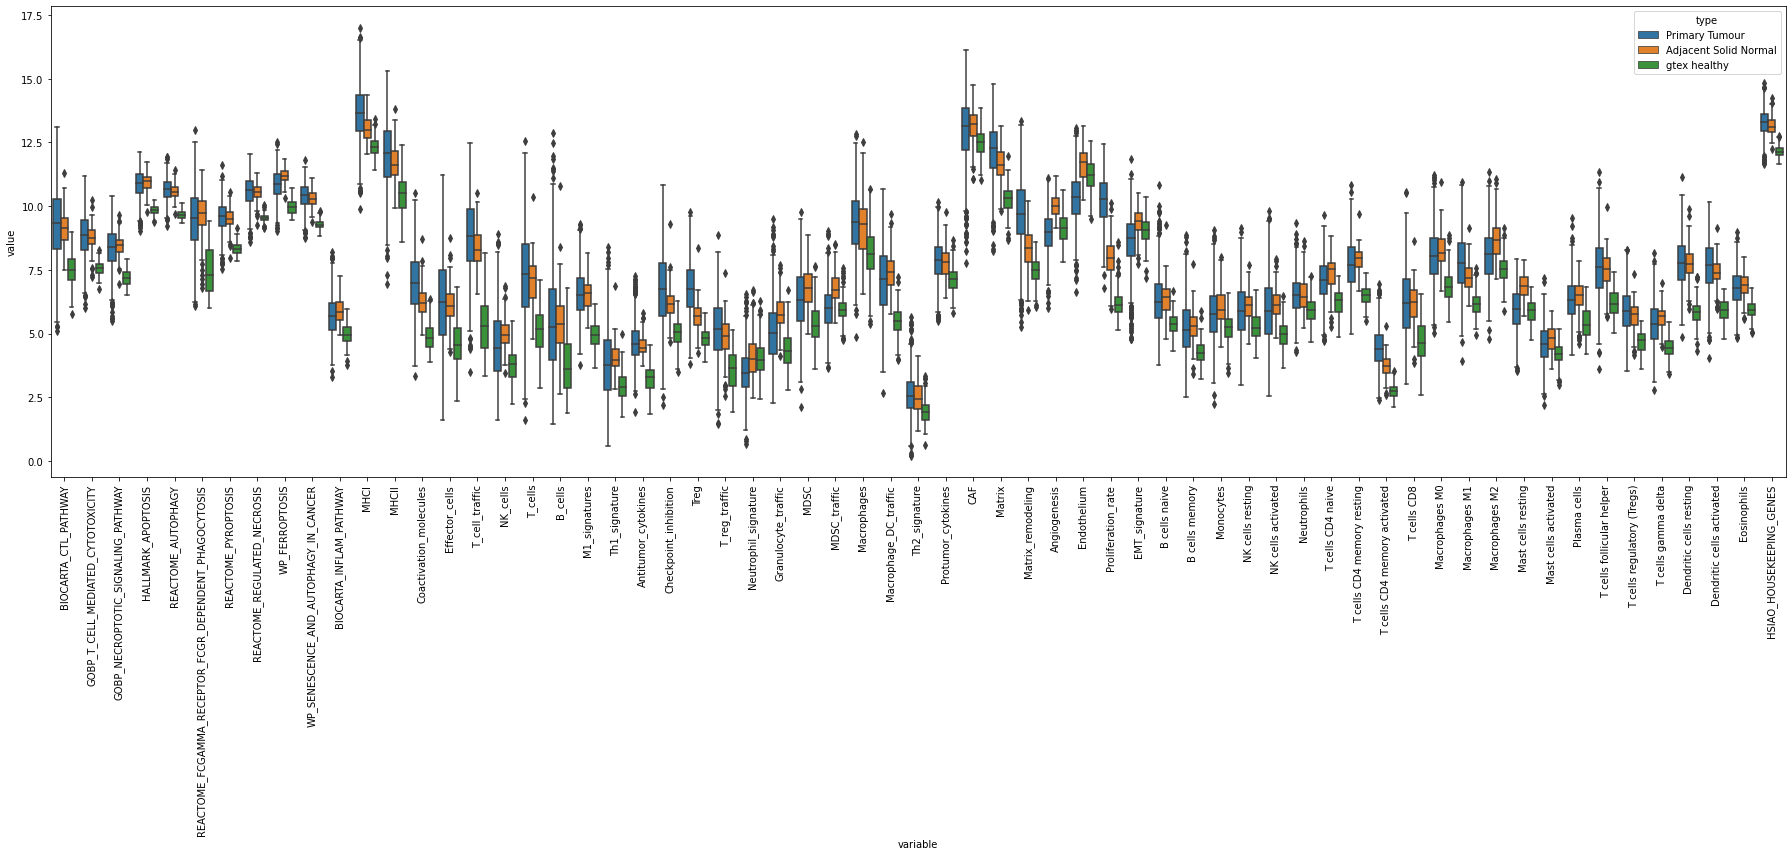

In [127]:
plt.figure(figsize=(25,12))
res=sns.boxplot(x='variable',y='value',data=dd, hue='type')
plt.xticks(rotation=90)
plt.tight_layout()
res.figure.savefig("mean_geneset_expression.png")

[Text(1, 0, 'REACTOME_AUTOPHAGY_geneset'),
 Text(2, 0, 'HALLMARK_APOPTOSIS_geneset'),
 Text(3, 0, 'GOBP_NECROPTOTIC_sig_geneset'),
 Text(4, 0, 'REACTOME_FCGR_DEPENDENT_PHAGOCYTOSIS_geneset'),
 Text(5, 0, 'GOBP_CTL_geneset'),
 Text(6, 0, 'inflammatory_geneset'),
 Text(7, 0, 'BIOCARTA_CTL_PATHWAY_geneset'),
 Text(8, 0, 'REACTOME_REGULATED_NECROSIS_geneset'),
 Text(9, 0, 'REACTOME_PYROPTOSIS_geneset'),
 Text(10, 0, 'WP_FERROPTOSIS_geneset'),
 Text(11, 0, 'WP_SENESCENCE_AND_AUTOPHAGY_IN_CANCER_geneset')]

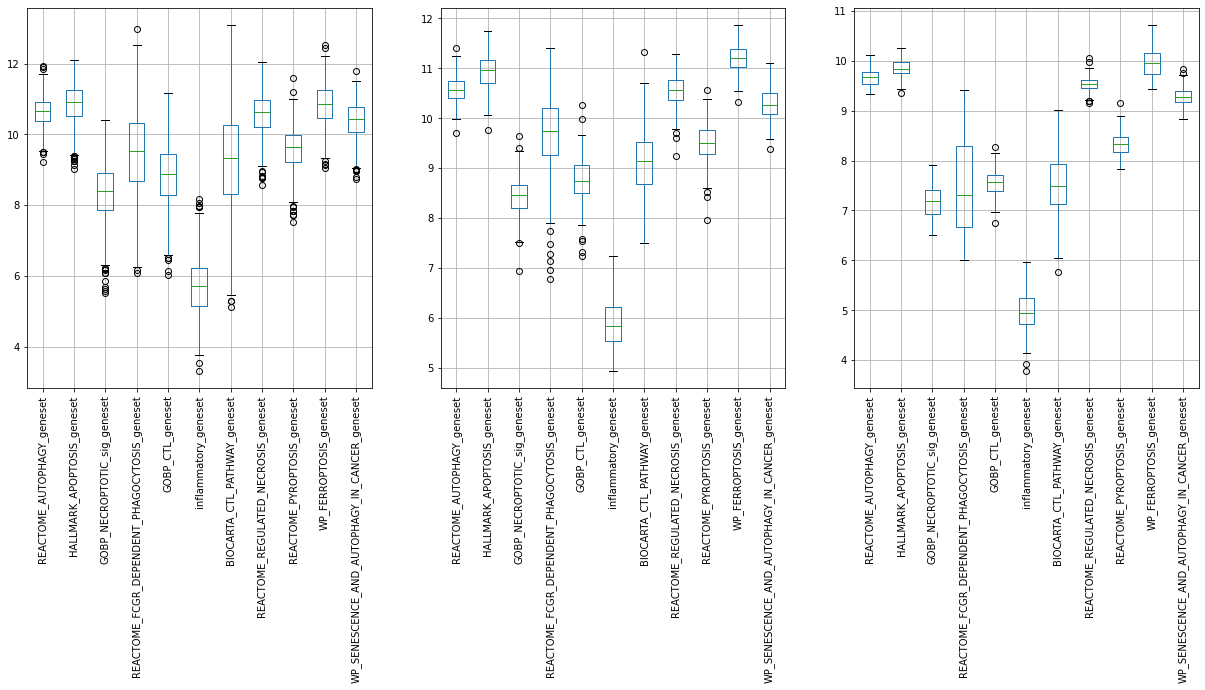

In [188]:
#mean expression
fig, ax = plt.subplots(nrows=1, ncols=3)
brcapt_cds_mge.transpose().boxplot(ax=ax[0])
ax[0].set_xticklabels(labels=brcapt_cds_mge.index,rotation=90)
brcasn_cds_mge.transpose().boxplot(ax=ax[1])
ax[1].set_xticklabels(labels=brcapt_cds_mge.index,rotation=90)
gtexbr_cds_mge.transpose().boxplot(ax=ax[2])
ax[2].set_xticklabels(labels=brcapt_cds_mge.index,rotation=90)

In [189]:
del genexpmatrix

In [191]:
mutationmatrix=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.mutect2_snv.tsv.gz",sep="\t",index_col=0)
nonsyn_mutmatrix=mutationmatrix.loc[~mutationmatrix["effect"].str.contains("synonymous_variant")].copy()

In [192]:
test=pd.crosstab(columns=nonsyn_mutmatrix.index, index=nonsyn_mutmatrix.gene)
test.head()

col_0,TCGA-02-0003-01A,TCGA-02-0033-01A,TCGA-02-0047-01A,TCGA-02-0055-01A,TCGA-02-2466-01A,TCGA-02-2470-01A,TCGA-02-2483-01A,TCGA-02-2485-01A,TCGA-02-2486-01A,TCGA-04-1331-01A,...,TCGA-ZP-A9D4-01A,TCGA-ZQ-A9CR-01A,TCGA-ZR-A9CJ-01B,TCGA-ZS-A9CD-01A,TCGA-ZS-A9CE-01A,TCGA-ZS-A9CF-01A,TCGA-ZS-A9CG-01A,TCGA-ZT-A8OM-01A,TCGA-ZU-A8S4-01A,TCGA-ZX-AA5X-01A
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2MP1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [193]:
mm_hgnclist=test.index.to_list()
mm_hgnclist
mm_enslist=[]
for g in mm_hgnclist:
    try:
        mm_enslist.append(tcgaensdict[g])
    except KeyError:
        print(g)
        mm_enslist.append(g)

AC104809.3
AC114494.1
AC138969.4
AL022328.1
B3GALTL
C12orf5
C14orf183
C17orf70
C19orf40
C19orf83
C1orf86
C2orf43
C6orf195
CCL4L1
CSNK2B-LY6G5B--991
DAK
FAIM3
IGJ
KAL1
KIAA1045
KIAA1279
KIAA1598
MIR4435-1HG
NBPF8P
PROSP
RP11-1220K2.2
RP11-162O12.2
RP11-350A1.1
RP11-38M15.11
RP11-396K3.1
RP11-402J6.2
RP11-536C10.25
RP11-551L14.1
RP11-642P15.1
RP11-683L23.1
RP11-944L7.5
RP13-7D7.1
RP5-907C10.4
RPSAP56
T1560
TMEM194A
TMEM194B
Unknown
ZSCAN5C
hsa-mir-6511b-1


In [194]:
test.index=mm_enslist
test.head()

col_0,TCGA-02-0003-01A,TCGA-02-0033-01A,TCGA-02-0047-01A,TCGA-02-0055-01A,TCGA-02-2466-01A,TCGA-02-2470-01A,TCGA-02-2483-01A,TCGA-02-2485-01A,TCGA-02-2486-01A,TCGA-04-1331-01A,...,TCGA-ZP-A9D4-01A,TCGA-ZQ-A9CR-01A,TCGA-ZR-A9CJ-01B,TCGA-ZS-A9CD-01A,TCGA-ZS-A9CE-01A,TCGA-ZS-A9CF-01A,TCGA-ZS-A9CG-01A,TCGA-ZT-A8OM-01A,TCGA-ZU-A8S4-01A,TCGA-ZX-AA5X-01A
ENSG00000121410,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000148584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000175899,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000166535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000256069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [195]:
def agg_mutations(df,geneset):
    newdf=pd.DataFrame(index=geneset.keys(),columns=df.columns)
    for g in geneset:
        newdf.loc[g]=df.loc[df.index.intersection(geneset[g]),:].sum()
    return(newdf)

In [205]:
brcapt_snv=test.loc[test.index.intersection(list(gsgenemap.values())),test.columns.intersection(can_dict['TCGA-BRCA'])].copy()

In [206]:
brcapt_snv

col_0,TCGA-3C-AAAU-01A,TCGA-3C-AALI-01A,TCGA-3C-AALJ-01A,TCGA-3C-AALK-01A,TCGA-4H-AAAK-01A,TCGA-5L-AAT0-01A,TCGA-5L-AAT1-01A,TCGA-5T-A9QA-01A,TCGA-A1-A0SD-01A,TCGA-A1-A0SE-01A,...,TCGA-UL-AAZ6-01A,TCGA-UU-A93S-01A,TCGA-V7-A7HQ-01A,TCGA-W8-A86G-01A,TCGA-WT-AB41-01A,TCGA-WT-AB44-01A,TCGA-XX-A899-01A,TCGA-XX-A89A-01A,TCGA-Z7-A8R5-01A,TCGA-Z7-A8R6-01A
ENSG00000136754,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000138443,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000097007,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000151726,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000123983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000070540,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000157954,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000143184,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000101966,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [211]:
brcapt_aggcds=agg_mutations(brcapt_snv,ensgeneset)
brcapt_aggcds.fillna(0,inplace=True)

(-1.0, 5.0)

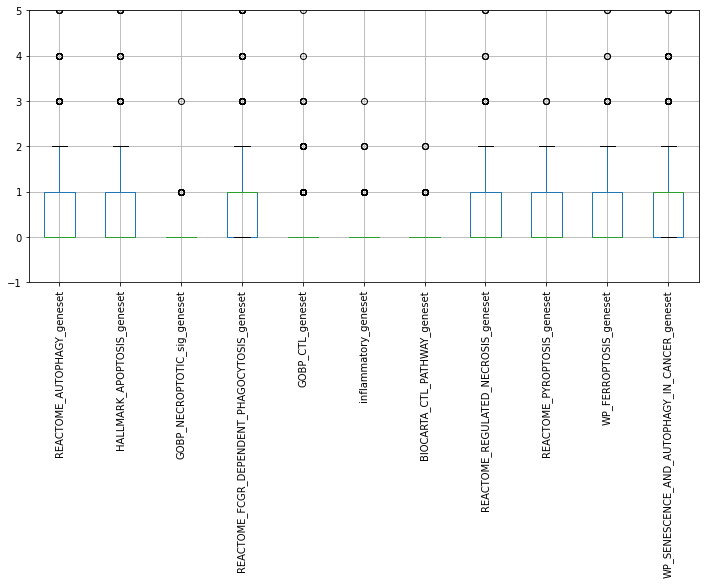

In [217]:
#aggmutations
plt.rcParams["figure.figsize"] = (12,5)
brcapt_aggcds.transpose().boxplot()
plt.xticks(rotation=90)
plt.ylim(-1,5)

In [202]:
cat_sample=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.basic_phenotype.tsv", sep="\t",index_col=0)
cat_sample.dropna(inplace=True)
cat_sample.drop(cat_sample.loc[cat_sample['sample_type'].str.contains("Normal")].index,inplace=True)
cat_sdit=dict(cat_sample['project_id'])

In [203]:
can_dict={}
for s in cat_sdit:
    if cat_sdit[s] not in can_dict.keys():
        can_dict[cat_sdit[s]]=[]
        can_dict[cat_sdit[s]].append(s)
    else:
        can_dict[cat_sdit[s]].append(s)